In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bronx_2025_sample.csv", low_memory=False)
print(df.shape)
df.head()

(100000, 44)


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
0,67074542,2025-12-06 07:12:45,12/06/2025 08:41:22 AM,NYPD,New York City Police Department,Noise - Residential,Loud Music/Party,NaN,Residential Building/House,10466.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.891872,-73.860168,POINT (-73.860168452965 40.891872416493)
1,66094289,2025-09-08 20:25:10,09/18/2025 05:15:51 PM,HPD,Department of Housing Preservation and Develop...,APPLIANCE,ELECTRIC/GAS RANGE,PILOT LIGHT OUT,RESIDENTIAL BUILDING,10458.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.873917,-73.884932,POINT (-73.884931661239 40.873916546646)
2,65642148,2025-07-23 14:50:04,07/23/2025 03:51:55 PM,DOT,Department of Transportation,Street Condition,Crash Cushion Defect,NaN,Street,10465.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.825146,-73.823866,POINT (-73.823865530821 40.825145602562)
3,64588257,2025-04-08 22:08:04,04/09/2025 07:38:17 AM,NYPD,New York City Police Department,Noise - Residential,Loud Talking,NaN,Residential Building/House,10452.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835962,-73.916307,POINT (-73.916307480709 40.83596236714)
4,67265751,2025-12-22 15:54:55,12/24/2025 05:11:18 PM,HPD,Department of Housing Preservation and Develop...,PAINT/PLASTER,CEILING,COLLAPSING OR FALLING,RESIDENTIAL BUILDING,10458.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.856946,-73.893814,POINT (-73.893814071369 40.856946355641)


In [36]:
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')

In [37]:
df_filtered = df[
    (df['Borough'] == 'BRONX') &
    (df['Created Date'].dt.year == 2025)
]

In [38]:
df_filtered.shape

(100000, 44)

In [39]:
df_filtered = df.copy()

In [40]:
df_sample = df_filtered.sample(n=100000, random_state=42)

In [41]:
df_sample.to_csv("bronx_2025_sample.csv", index=False)

In [42]:
df_sample['Closed Date'] = pd.to_datetime(df_sample['Closed Date'], errors='coerce')

df_sample['resolution_time'] = (
    df_sample['Closed Date'] - df_sample['Created Date']
).dt.total_seconds() / 3600

/var/folders/73/h5y8p1fd7x38r1c25p3082rr0000gn/T/ipykernel_1541/774120829.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sample['Closed Date'] = pd.to_datetime(df_sample['Closed Date'], errors='coerce')


In [43]:
df_sample = df_sample[df_sample['resolution_time'] > 0]

In [44]:
df_sample = df_sample.rename(columns={
    'Problem (formerly Complaint Type)': 'Complaint Type'
})

In [45]:
top_complaints = df_sample['Complaint Type'].value_counts().head(10).index

df_top = df_sample[df_sample['Complaint Type'].isin(top_complaints)]

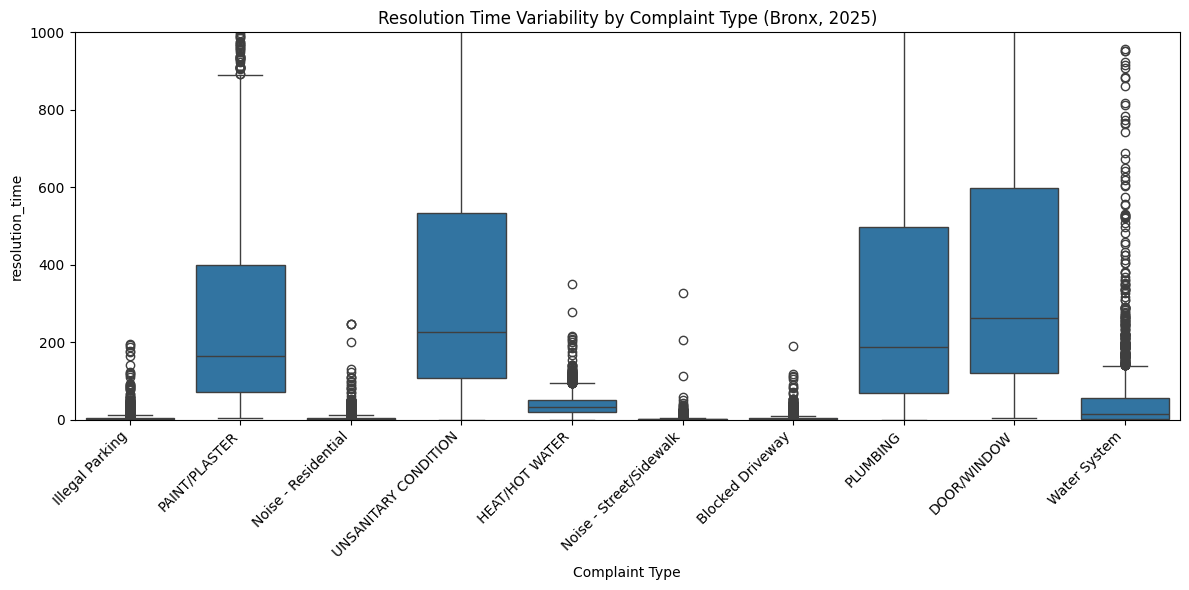

In [46]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_top,
    x='Complaint Type',
    y='resolution_time'
)

plt.xticks(rotation=45, ha='right')
plt.title("Resolution Time Variability by Complaint Type (Bronx, 2025)")
plt.tight_layout()
plt.ylim(0, 1000)
plt.show()

In [47]:
df_sample['Status'].value_counts()

Status
Closed         96782
Assigned          40
Unspecified       17
Started            1
Name: count, dtype: int64

In [48]:
df_sample['long_resolution'] = df_sample['resolution_time'] > 72

In [49]:
long_rates = df_sample.groupby('Complaint Type')['long_resolution'].mean().sort_values(ascending=False)

In [50]:
long_rates_top = long_rates[top_complaints]

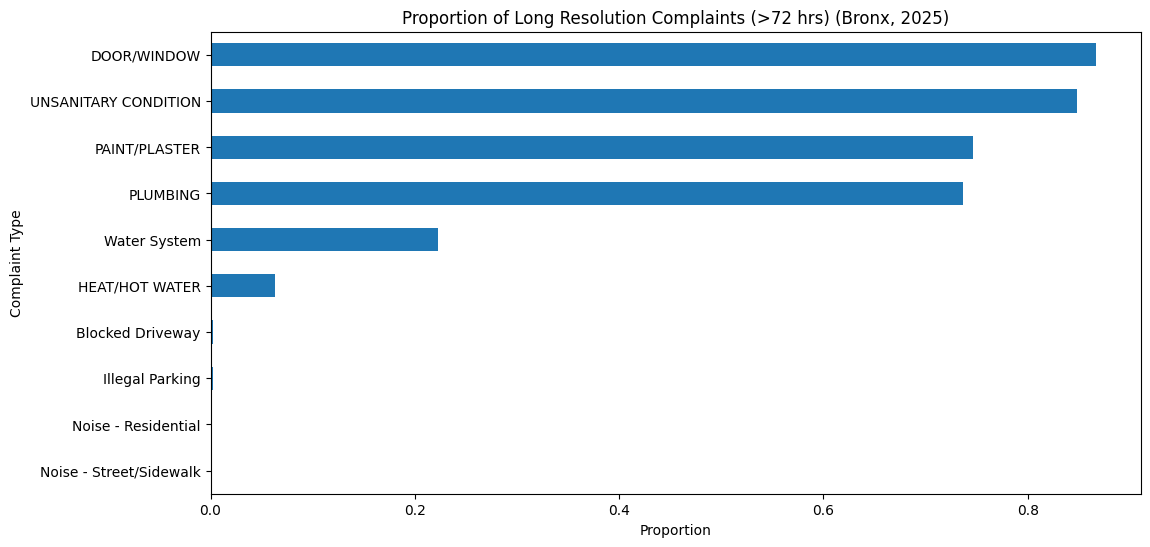

In [51]:
plt.figure(figsize=(12,6))

long_rates_top.sort_values().plot(kind='barh')

plt.title("Proportion of Long Resolution Complaints (>72 hrs) (Bronx, 2025)")
plt.xlabel("Proportion")
plt.ylabel("Complaint Type")

plt.show()

In [52]:
df_sample['month'] = df_sample['Created Date'].dt.month

In [53]:
monthly_counts = df_sample['month'].value_counts().sort_index()

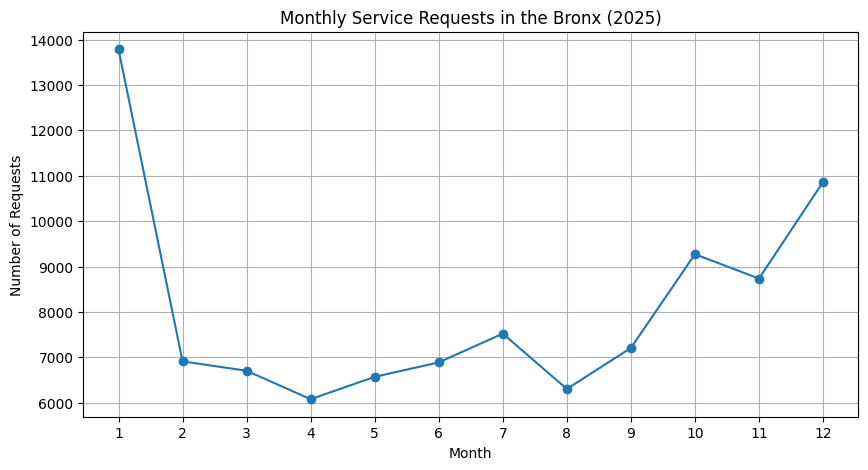

In [34]:
plt.figure(figsize=(10,5))

monthly_counts.plot(kind='line', marker='o')

plt.title("Monthly Service Requests in the Bronx (2025)")
plt.xlabel("Month")
plt.ylabel("Number of Requests")

plt.xticks(range(1,13))
plt.grid()

plt.show()